In [1]:
import os
import gc
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.table import Table
from IPython.display import Image, display

plt.rcdefaults()
plt.rcParams['font.family'] = 'Liberation Serif'
plt.rcParams['axes.linewidth'] = 1.2


In [2]:
def load_fits_df(path):
    tab = Table.read(path, format='fits', memmap=True)
    df = tab.to_pandas()
    for col in df.columns:
        df[col] = df[col].apply(lambda x: x.decode() if isinstance(x, bytes) else x)
    return df


def get_zone_paths(raw_dir, prob_dir, zone):
    raw_path = os.path.join(raw_dir, f'zone_{zone:02d}.fits.gz')
    prob_path = os.path.join(prob_dir, f'zone_{zone:02d}_probability.fits.gz')
    return raw_path, prob_path


def compute_entropy(df):
    cols = ['PVOID', 'PSHEET', 'PFILAMENT', 'PKNOT']
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise KeyError(f'Missing probability columns: {missing}')

    probs = np.column_stack([np.asarray(df[c], dtype=float) for c in cols])
    probs = np.clip(probs, 0.0, 1.0)

    with np.errstate(divide='ignore', invalid='ignore'):
        terms = probs * np.log2(probs)
    terms[~np.isfinite(terms)] = 0.0

    # Normalized Shannon entropy in [0, 1] for 4 classes
    h = -np.sum(terms, axis=1) / np.log2(4.0)

    out = df.copy()
    out['H'] = h.astype(np.float32)
    return out


In [3]:
def plot_pdf_entropy_with_dispersion(
    raw_dir,
    prob_dir,
    zones,
    out_dir,
    tracers=None,
    sample='DATA',
    bins=16,
    range_H=(0.0, 1.0),
    progress=True,
):
    if tracers is None:
        tracers = ['BGS_ANY', 'LRG', 'ELG', 'QSO']

    sample = sample.upper()
    if sample not in {'DATA', 'RAND'}:
        raise ValueError("sample must be 'DATA' or 'RAND'")

    per_tracer_sum = {t: None for t in tracers}
    per_tracer_sum2 = {t: None for t in tracers}
    per_tracer_count = {t: 0 for t in tracers}

    for i, z in enumerate(zones):
        if progress:
            print(f'Processing zone {z} ({i+1}/{len(zones)})')

        raw_path, prob_path = get_zone_paths(raw_dir, prob_dir, z)
        raw_df = load_fits_df(raw_path)
        prob_df = load_fits_df(prob_path)

        raw_df['RAW_TRACER'] = raw_df['TRACERTYPE'].astype(str)
        raw_df['BASE_TRACER'] = raw_df['RAW_TRACER'].str.replace('_DATA', '', regex=False).str.replace('_RAND', '', regex=False)

        prob_df = prob_df.rename(columns={'TRACERTYPE': 'BASE_TRACER'})
        prob_df['BASE_TRACER'] = prob_df['BASE_TRACER'].astype(str)

        # Probability files do not include RANDITER; merge using TARGETID + base tracer
        merged = raw_df.merge(prob_df, on=['TARGETID', 'BASE_TRACER'], how='inner')

        merged = compute_entropy(merged)

        for tr in tracers:
            sub = merged[(merged['BASE_TRACER'] == tr)]
            h_vals = sub['H'].to_numpy()

            if h_vals.size == 0:
                continue

            hist, _ = np.histogram(h_vals, bins=bins, range=range_H, density=True)

            if per_tracer_sum[tr] is None:
                per_tracer_sum[tr] = hist
                per_tracer_sum2[tr] = hist ** 2
            else:
                per_tracer_sum[tr] += hist
                per_tracer_sum2[tr] += hist ** 2
            per_tracer_count[tr] += 1

        del raw_df, prob_df, merged
        gc.collect()

    os.makedirs(out_dir, exist_ok=True)

    bin_edges = np.linspace(range_H[0], range_H[1], bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    tracer_color_map = {'BGS_ANY': 'blue', 'LRG': 'green', 'ELG': 'red', 'QSO': 'purple'}

    fig, ax = plt.subplots(figsize=(14, 10))
    ax.grid(linewidth=0.5, alpha=0.5, linestyle='--')

    for tr in tracers:
        count = per_tracer_count[tr]
        if count == 0:
            continue

        mean = per_tracer_sum[tr] / count
        var = (per_tracer_sum2[tr] / count) - mean ** 2
        std = np.sqrt(np.maximum(var, 0.0))

        tracer_data = {
            'TRACER': tr,
            'SAMPLE': sample,
            'BIN_CENTERS': bin_centers,
            'MEAN': mean,
            'STD': std,
            'COUNT': count,
        }

        pkl_path = os.path.join(out_dir, f'{tr}_{sample.lower()}_entropy.pkl')
        with open(pkl_path, 'wb') as f:
            pickle.dump(tracer_data, f, protocol=pickle.HIGHEST_PROTOCOL)
        print(f'Saved: {pkl_path}')

        color = tracer_color_map.get(tr, 'black')
        label = 'BGS' if tr == 'BGS_ANY' else tr
        ax.fill_between(bin_centers, mean - std, mean + std, alpha=0.15, color=color)
        ax.plot(bin_centers, mean, linewidth=2.5, color=color, label=label)

    ax.set_xlabel('Normalized Shannon Entropy H', fontsize=29)
    ax.set_ylabel('PDF', fontsize=29)
    ax.tick_params(axis='both', labelsize=23)
    ax.set_xlim(range_H)

    fig.subplots_adjust(bottom=0.22)
    bb = ax.get_position()
    fig.legend(
        *ax.get_legend_handles_labels(),
        loc='upper left',
        ncol=4,
        frameon=True,
        fontsize=20,
        mode='expand',
        bbox_to_anchor=(bb.x0, bb.y0 - 0.12, bb.width, 0.001),
        bbox_transform=fig.transFigure,
        borderaxespad=0.0,
        columnspacing=5,
        handlelength=2.5,
    )

    zones_label = f'{min(zones)}_{max(zones)}' if len(zones) > 0 else 'none'
    fig_path = f'/Users/soguevaram/Desktop/Research/DESI/plots/pdf_entropy.png'
    fig.savefig(fig_path, dpi=360, bbox_inches='tight')
    plt.close(fig)
    print(f'Saved figure: {fig_path}')

    return fig_path


Processing zone 0 (1/20)
Processing zone 1 (2/20)
Processing zone 2 (3/20)
Processing zone 3 (4/20)
Processing zone 4 (5/20)
Processing zone 5 (6/20)
Processing zone 6 (7/20)
Processing zone 7 (8/20)
Processing zone 8 (9/20)
Processing zone 9 (10/20)
Processing zone 10 (11/20)
Processing zone 11 (12/20)
Processing zone 12 (13/20)
Processing zone 13 (14/20)
Processing zone 14 (15/20)
Processing zone 15 (16/20)
Processing zone 16 (17/20)
Processing zone 17 (18/20)
Processing zone 18 (19/20)
Processing zone 19 (20/20)
Saved: /Users/soguevaram/Desktop/Research/DESI/data/results/entropy/BGS_ANY_data_entropy.pkl
Saved: /Users/soguevaram/Desktop/Research/DESI/data/results/entropy/LRG_data_entropy.pkl
Saved: /Users/soguevaram/Desktop/Research/DESI/data/results/entropy/ELG_data_entropy.pkl
Saved: /Users/soguevaram/Desktop/Research/DESI/data/results/entropy/QSO_data_entropy.pkl
Saved figure: /Users/soguevaram/Desktop/Research/DESI/plots/pdf_entropy.png


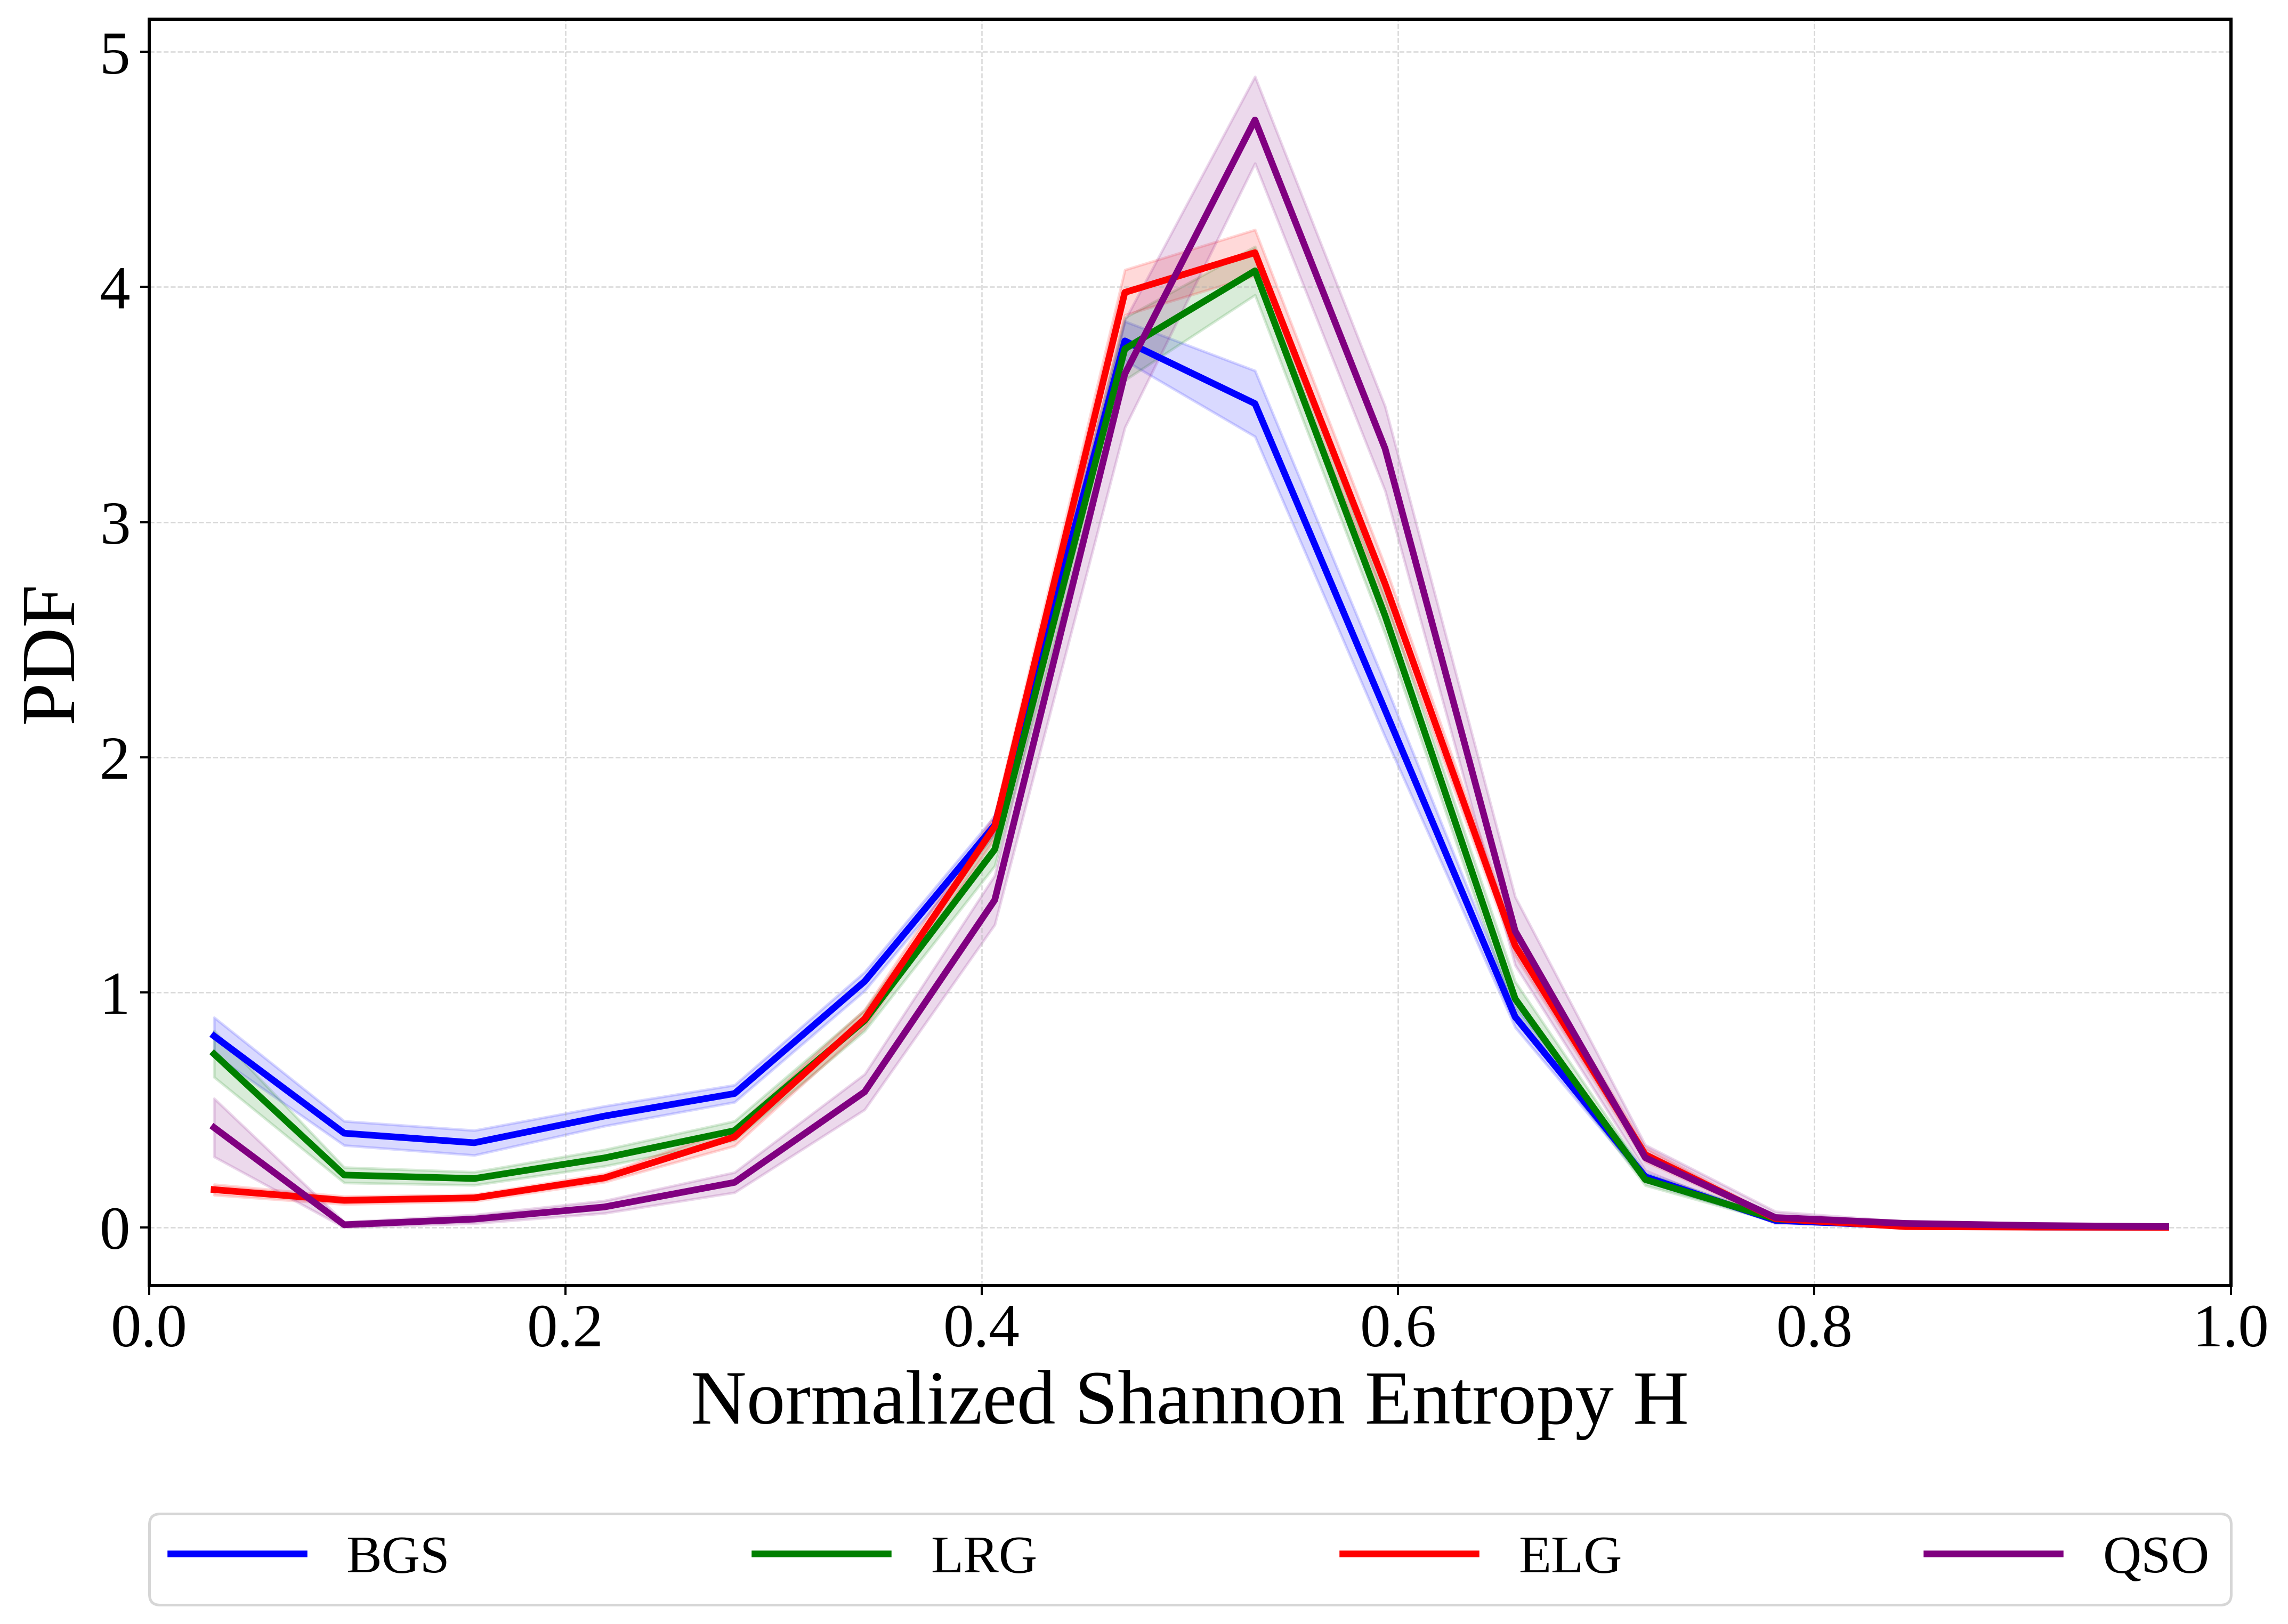

In [4]:
base_dir = '/Users/soguevaram/Desktop/Research/DESI/data/edr'
raw_dir = os.path.join(base_dir, 'raw')
prob_dir = os.path.join(base_dir, 'probabilities')
out_dir = '/Users/soguevaram/Desktop/Research/DESI/data/results/entropy'

# Use sample='DATA' for objects and sample='RAND' for random catalog
fig_path = plot_pdf_entropy_with_dispersion(
    raw_dir=raw_dir,
    prob_dir=prob_dir,
    zones=list(range(20)),
    out_dir=out_dir,
    sample='DATA',
)

display(Image(filename=fig_path))
